# Program 5: Next Word Predictor using RNN and LSTM

**Objective:** Train a next-word predictor using both RNN and LSTM architectures and compare their text generation capabilities.

### Tasks:
1. Load text data
2. Create input sequences, character vocabulary, and vectorize text
3. Create training sequences
4. Build RNN and LSTM models
5. Train both models
6. Write text generation function
7. Generate new text and validate

## Step 0: Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: []


---
## Task 1: Load Text Data

We generate a text corpus (~200 lines) covering Artificial Intelligence topics. This serves as our training data.

In [2]:


text_data = """Artificial intelligence is transforming every aspect of modern life and technology.
Machine learning algorithms can identify complex patterns hidden within massive datasets.
Deep learning models use multiple layers of neural networks to learn representations.
Natural language processing enables computers to understand and generate human language.
Computer vision allows machines to interpret and analyze visual information from images.
Reinforcement learning trains agents to make optimal decisions through trial and error.
Neural networks are inspired by the biological structure of the human brain.
Supervised learning requires labeled training data to learn input output mappings.
Unsupervised learning discovers hidden patterns in data without explicit labels.
Transfer learning allows models to apply knowledge learned from one task to another.
Recurrent neural networks are designed to process sequential data and time series.
Long short term memory networks can learn long range dependencies in sequences.
Convolutional neural networks excel at processing grid structured data like images.
Generative adversarial networks can create realistic synthetic data and images.
Attention mechanisms allow models to focus on relevant parts of the input sequence.
Transformer models have revolutionized natural language processing tasks completely.
The backpropagation algorithm is used to train deep neural network models efficiently.
Gradient descent optimization helps neural networks learn from training data iteratively.
Batch normalization improves the training speed and stability of deep networks.
Dropout regularization helps prevent overfitting in large neural network models.
Data augmentation techniques increase the effective size of training datasets significantly.
Hyperparameter tuning is essential for achieving optimal model performance results.
Cross validation helps evaluate model generalization on unseen data samples.
The bias variance tradeoff is fundamental to understanding model performance.
Ensemble methods combine multiple models to achieve better predictive performance.
Random forests use multiple decision trees to make robust predictions.
Gradient boosting builds models sequentially to correct errors of previous models.
Support vector machines find optimal hyperplanes to separate different classes.
Principal component analysis reduces dimensionality while preserving important variance.
Clustering algorithms group similar data points together without supervision.
Feature engineering creates meaningful input variables from raw data sources.
Feature selection identifies the most relevant variables for model training.
Dimensionality reduction techniques simplify complex high dimensional datasets.
The curse of dimensionality makes learning difficult in high dimensional spaces.
Regularization techniques help prevent models from memorizing training data exactly.
Learning rate scheduling adjusts the optimization step size during training.
Early stopping prevents overfitting by monitoring validation loss during training.
Weight initialization strategies affect the convergence of deep learning models.
Activation functions introduce nonlinearity into neural network computations.
The sigmoid function maps values to a range between zero and one smoothly.
The relu activation function has become the default choice for hidden layers.
Softmax activation converts network outputs into probability distributions.
Loss functions measure the difference between predicted and actual values.
Cross entropy loss is commonly used for classification tasks in deep learning.
Mean squared error is the standard loss function for regression problems.
Optimizers like adam combine momentum and adaptive learning rate methods.
Stochastic gradient descent processes random subsets of training data efficiently.
Mini batch training balances computation efficiency and gradient estimation quality.
Epoch refers to one complete pass through the entire training dataset.
Overfitting occurs when a model performs well on training but poorly on test data.
Underfitting happens when a model is too simple to capture underlying patterns.
The training loss typically decreases as the model learns from the data.
Validation loss helps monitor model performance on held out data during training.
Test accuracy provides the final evaluation of model performance on new data.
Confusion matrices show the detailed classification performance across all classes.
Precision measures the proportion of positive predictions that are actually correct.
Recall measures the proportion of actual positives correctly identified by model.
The F1 score combines precision and recall into a single balanced metric.
ROC curves visualize the tradeoff between true positive and false positive rates.
Area under the curve provides an aggregate measure of classification performance.
Word embeddings represent words as dense vectors in continuous vector spaces.
Word2vec learns distributed word representations from large text corpora.
GloVe embeddings capture global statistical information about word co occurrence.
Sentiment analysis determines the emotional tone expressed in text data.
Named entity recognition identifies and classifies entities mentioned in text.
Machine translation converts text from one human language to another automatically.
Text summarization produces concise summaries of longer documents automatically.
Question answering systems extract relevant answers from given text passages.
Chatbots use natural language processing to simulate human conversation.
Speech recognition converts spoken language into written text accurately.
Text classification assigns predefined categories to text documents automatically.
Topic modeling discovers abstract themes present within collections of documents.
Language models predict the probability of word sequences in natural language.
Perplexity measures how well a language model predicts a given text sample.
Tokenization breaks text into individual words or subword units for processing.
Stemming reduces words to their base or root form for text analysis.
Lemmatization converts words to their dictionary form considering context.
Stop words are commonly occurring words that carry little meaningful information.
TF IDF measures the importance of words relative to a document collection.
Bag of words represents text as unordered collections of word frequencies.
N gram models capture local word order patterns within text sequences.
Sequence to sequence models transform one sequence into another different sequence.
Encoder decoder architectures first compress input then generate output sequences.
Beam search explores multiple candidate sequences during text generation.
Greedy decoding selects the most probable token at each generation step.
Temperature sampling controls the randomness of text generation outputs.
Top k sampling restricts generation to the k most probable next tokens.
Nucleus sampling dynamically adjusts the candidate token set during generation.
Image classification assigns category labels to input images automatically.
Object detection identifies and locates multiple objects within images precisely.
Semantic segmentation assigns a class label to every pixel in an image.
Instance segmentation distinguishes between different instances of the same object.
Image generation creates new realistic images from learned data distributions.
Style transfer applies the artistic style of one image to another image.
Face recognition identifies or verifies individuals from facial images accurately.
Pose estimation determines the position of body joints from image data.
Optical character recognition extracts text content from images of documents.
Medical imaging uses deep learning to assist in disease diagnosis and detection.
Autonomous vehicles use multiple sensors and deep learning for navigation safely.
Robotics combines perception planning and control for intelligent physical agents.
Recommendation systems suggest relevant items based on user preferences and behavior.
Collaborative filtering makes predictions based on similar user behavior patterns.
Content based filtering recommends items similar to what users liked before.
Anomaly detection identifies unusual patterns that deviate from normal behavior.
Fraud detection uses machine learning to identify suspicious financial transactions.
Time series forecasting predicts future values based on historical temporal data.
Speech synthesis generates natural sounding human speech from text input.
Music generation uses neural networks to compose original musical pieces.
Drug discovery applies deep learning to identify promising molecular compounds.
Protein structure prediction uses neural networks to determine molecular shapes.
Climate modeling applies machine learning to predict weather and climate patterns.
Financial modeling uses algorithms to predict market trends and asset prices.
Natural language generation produces coherent text from structured data inputs.
Dialogue systems manage multi turn conversations with users naturally.
Information retrieval finds relevant documents from large text collections.
Knowledge graphs represent structured relationships between real world entities.
Federated learning trains models across distributed devices while preserving privacy.
Differential privacy adds noise to protect individual data during model training.
Model compression reduces the size of neural networks for efficient deployment.
Quantization reduces the precision of model weights to decrease memory usage.
Knowledge distillation transfers knowledge from large models to smaller ones.
Pruning removes unnecessary connections to create smaller more efficient networks.
Edge computing deploys machine learning models directly on local devices.
Cloud computing provides scalable resources for training large neural networks.
GPU acceleration dramatically speeds up the training of deep learning models.
Distributed training splits model training across multiple computing devices.
AutoML automates the process of selecting and tuning machine learning models.
Neural architecture search automatically designs optimal network architectures.
Meta learning teaches models to learn new tasks quickly from few examples.
Few shot learning enables models to generalize from very limited training examples.
Zero shot learning allows models to recognize classes not seen during training.
Continual learning enables models to learn new tasks without forgetting old ones.
Curriculum learning presents training examples in a meaningful ordered sequence.
Active learning selects the most informative examples for human labeling.
Self supervised learning creates supervisory signals from the input data itself.
Contrastive learning trains models by comparing similar and dissimilar pairs.
Multi task learning trains models on multiple related tasks simultaneously.
Multi modal learning processes and combines information from different modalities.
Graph neural networks process data structured as nodes and edges naturally.
Variational autoencoders learn latent representations for data generation tasks.
Normalizing flows transform simple distributions into complex data distributions.
Energy based models define probability distributions through energy functions.
Bayesian neural networks incorporate uncertainty estimation into predictions.
Gaussian processes provide probabilistic predictions with uncertainty quantification.
Causal inference determines cause and effect relationships from observational data.
Explainable artificial intelligence makes model decisions interpretable to humans.
Fairness in machine learning ensures models do not discriminate against groups.
Adversarial robustness protects models against carefully crafted malicious inputs.
Data poisoning attacks corrupt training data to manipulate model behavior.
Model interpretability helps understand why models make specific predictions.
Attention visualization shows which input features models focus on most.
Saliency maps highlight the most important regions in input images.
SHAP values explain individual predictions using game theory principles.
Ethics in artificial intelligence considers the societal impact of AI systems.
Responsible development of AI systems requires careful consideration of potential harms.
Bias in training data can lead to unfair and discriminatory model outputs.
Privacy preserving machine learning protects sensitive user data during training.
Synthetic data generation creates artificial datasets for training machine learning models.
Data labeling requires significant human effort and expertise for quality results.
Annotation tools help streamline the data labeling process for training datasets.
Benchmark datasets provide standardized evaluation criteria for comparing different models.
Open source frameworks like tensorflow and pytorch democratize deep learning research.
Research papers advance the state of the art in machine learning continuously.
Reproducibility in machine learning research ensures results can be verified independently.
The field of artificial intelligence continues to grow and evolve rapidly every year.
Deep learning has achieved remarkable breakthroughs across many different application domains.
The future of artificial intelligence holds tremendous promise for solving global challenges.
Artificial intelligence research requires collaboration across multiple scientific disciplines.
Machine learning models are becoming increasingly powerful and efficient over time.
The development of artificial intelligence systems demands careful ethical considerations always.
Neural network architectures continue to improve with new research and innovations.
The intersection of artificial intelligence and other fields creates exciting new opportunities.
Deep learning applications continue to expand into new domains and industries rapidly.
Understanding the fundamentals of machine learning is essential for modern data scientists.
The rapid advancement of artificial intelligence technology is reshaping industries worldwide.
Machine learning engineers must understand both theory and practical implementation details.
The success of deep learning depends on quality data and computational resources.
Artificial intelligence applications are becoming an integral part of daily human life."""


with open('training_text.txt', 'w') as f:
    f.write(text_data)


with open('training_text.txt', 'r') as f:
    text = f.read()

lines = text.split('\n')
print(f"Total characters : {len(text)}")
print(f"Total lines      : {len(lines)}")
print(f"\nFirst 5 lines:")
for line in lines[:5]:
    print(f"  {line}")

Total characters : 14386
Total lines      : 178

First 5 lines:
  Artificial intelligence is transforming every aspect of modern life and technology.
  Machine learning algorithms can identify complex patterns hidden within massive datasets.
  Deep learning models use multiple layers of neural networks to learn representations.
  Natural language processing enables computers to understand and generate human language.
  Computer vision allows machines to interpret and analyze visual information from images.


---
## Task 2: Create Input Sequences, Vocabulary, and Vectorize Text

We tokenize the text at the **word level**, build a vocabulary, and create n-gram input sequences.

In [3]:

corpus = text.lower().replace('\n', ' ')


tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1   

print(f"Vocabulary size (unique words): {total_words}")
print(f"\nSample word → index mapping (first 20):")
for i, (word, idx) in enumerate(tokenizer.word_index.items()):
    if i >= 20:
        break
    print(f"  '{word}' → {idx}")

Vocabulary size (unique words): 825

Sample word → index mapping (first 20):
  'the' → 1
  'to' → 2
  'learning' → 3
  'of' → 4
  'and' → 5
  'data' → 6
  'models' → 7
  'training' → 8
  'from' → 9
  'text' → 10
  'for' → 11
  'model' → 12
  'in' → 13
  'neural' → 14
  'networks' → 15
  'machine' → 16
  'deep' → 17
  'on' → 18
  'artificial' → 19
  'intelligence' → 20


---
## Task 3: Create Training Sequences

From each line we generate multiple n-gram sequences. For a sentence of length *n*, we create sequences of lengths 2, 3, …, *n*, each time using all words except the last as input and the last word as the target.

In [4]:


input_sequences = []

for line in text.lower().split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

max_seq_len = max(len(seq) for seq in input_sequences)
input_sequences = tf.keras.preprocessing.sequence.pad_sequences(
    input_sequences, maxlen=max_seq_len, padding='pre'
)

X = input_sequences[:, :-1]  
y = input_sequences[:, -1]    


y = to_categorical(y, num_classes=total_words)

print(f"Number of training sequences : {len(X)}")
print(f"Input sequence length (padded): {max_seq_len - 1}")
print(f"Output classes (vocab size)   : {total_words}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nExample — X[50]: {X[50][-10:]}  →  y[50] (argmax): {np.argmax(y[50])}")

Number of training sequences : 1702
Input sequence length (padded): 13
Output classes (vocab size)   : 825

X shape: (1702, 13)
y shape: (1702, 825)

Example — X[50]: [280 281  97 154   2 282   5 283 284  52]  →  y[50] (argmax): 9


---
## Task 4: Build RNN Model and LSTM Model

We build two separate models with identical structure except for the recurrent layer type.

In [5]:


def build_rnn_model(vocab_size, seq_length, embedding_dim=64, rnn_units=128):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=seq_length),
        SimpleRNN(rnn_units, return_sequences=True),
        Dropout(0.2),
        SimpleRNN(rnn_units),
        Dropout(0.2),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

rnn_model = build_rnn_model(total_words, max_seq_len - 1)
print("═" * 60)
print("            SIMPLE RNN MODEL SUMMARY")
print("═" * 60)
rnn_model.summary()

════════════════════════════════════════════════════════════
            SIMPLE RNN MODEL SUMMARY
════════════════════════════════════════════════════════════


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:


def build_lstm_model(vocab_size, seq_length, embedding_dim=64, lstm_units=128):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=seq_length),
        LSTM(lstm_units, return_sequences=True),
        Dropout(0.2),
        LSTM(lstm_units),
        Dropout(0.2),
        Dense(vocab_size, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_model(total_words, max_seq_len - 1)
print("═" * 60)
print("              LSTM MODEL SUMMARY")
print("═" * 60)
lstm_model.summary()

════════════════════════════════════════════════════════════
              LSTM MODEL SUMMARY
════════════════════════════════════════════════════════════


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## Task 5: Train Both Models

In [7]:


EPOCHS = 50

early_stop = EarlyStopping(
    monitor='loss', patience=5, restore_best_weights=True
)

print("Training Simple RNN Model...")
print("=" * 40)
rnn_history = rnn_model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
print("\nRNN Training Complete!")

Training Simple RNN Model...
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.0099 - loss: 6.6200
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0229 - loss: 6.1200
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0297 - loss: 5.9711
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0371 - loss: 5.8878
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.0543 - loss: 5.8181
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.0624 - loss: 5.6680
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1005 - loss: 5.4672
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1193 - loss: 5.2193
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1427 - loss: 4.9883
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1971 - loss: 4.6190
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2625 - loss: 4.3150
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━

In [8]:


early_stop_lstm = EarlyStopping(
    monitor='loss', patience=5, restore_best_weights=True
)

print("Training LSTM Model...")
print("=" * 40)
lstm_history = lstm_model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=64,
    callbacks=[early_stop_lstm],
    verbose=1
)
print("\nLSTM Training Complete!")

Training LSTM Model...
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.0137 - loss: 6.6620
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.0252 - loss: 6.0592
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.0254 - loss: 6.0540
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.0216 - loss: 6.0172
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.0344 - loss: 6.0017
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.0236 - loss: 5.9682
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.0306 - loss: 5.9717
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.0329 - loss: 5.9287
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.0313 - loss: 5.9642
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.0434 - loss: 5.8753
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.0543 - loss: 5.7953
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 

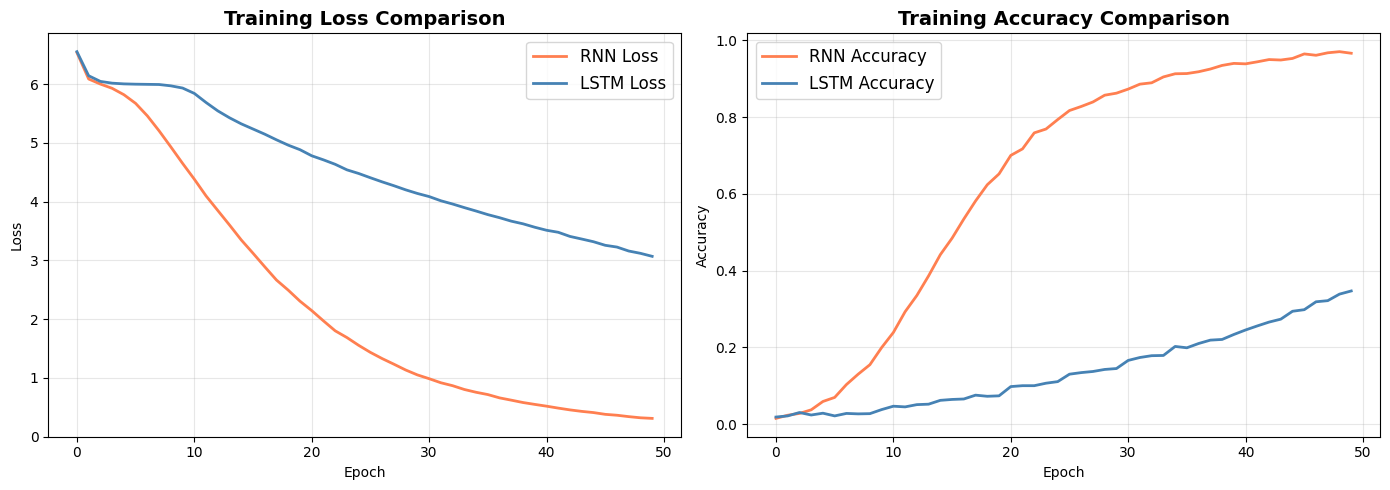


Final RNN  — Loss: 0.3112 | Accuracy: 0.9665
Final LSTM — Loss: 3.0685 | Accuracy: 0.3472


In [9]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(rnn_history.history['loss'], label='RNN Loss', color='coral', linewidth=2)
axes[0].plot(lstm_history.history['loss'], label='LSTM Loss', color='steelblue', linewidth=2)
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(rnn_history.history['accuracy'], label='RNN Accuracy', color='coral', linewidth=2)
axes[1].plot(lstm_history.history['accuracy'], label='LSTM Accuracy', color='steelblue', linewidth=2)
axes[1].set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal RNN  — Loss: {rnn_history.history['loss'][-1]:.4f} | Accuracy: {rnn_history.history['accuracy'][-1]:.4f}")
print(f"Final LSTM — Loss: {lstm_history.history['loss'][-1]:.4f} | Accuracy: {lstm_history.history['accuracy'][-1]:.4f}")

---
## Task 6: Text Generation Function

Given a seed phrase, the function predicts the next word iteratively to generate a sequence of a desired length.

In [10]:


def generate_text(model, tokenizer, seed_text, num_words, max_seq_len, temperature=1.0):
    """
    Generate text word-by-word using a trained model.

    Parameters:
        model       : trained Keras model
        tokenizer   : fitted Keras Tokenizer
        seed_text   : initial text prompt
        num_words   : number of words to generate
        max_seq_len : maximum padded sequence length (same as training)
        temperature : controls randomness (lower = more deterministic)

    Returns:
        The seed text extended with generated words.
    """
    result = seed_text.lower()

    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = tf.keras.preprocessing.sequence.pad_sequences(
            [token_list], maxlen=max_seq_len, padding='pre'
        )


        predictions = model.predict(token_list, verbose=0)[0]

        predictions = np.log(predictions + 1e-8) / temperature
        exp_preds = np.exp(predictions)
        predictions = exp_preds / np.sum(exp_preds)

    
        predicted_index = np.random.choice(len(predictions), p=predictions)

        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        result += ' ' + output_word

    return result

print("Text generation function defined successfully!")

Text generation function defined successfully!


---
## Task 7: Generate New Text and Validate

We test both models with several seed phrases and different temperature settings.

In [11]:


seed_phrases = [
    "deep learning",
    "neural networks are",
    "machine learning models",
    "artificial intelligence",
    "natural language"
]

NUM_WORDS = 10
seq_len = max_seq_len - 1

print("═" * 70)
print("        TEXT GENERATION — RNN vs LSTM  (temperature = 0.7)")
print("═" * 70)

for seed in seed_phrases:
    rnn_text  = generate_text(rnn_model,  tokenizer, seed, NUM_WORDS, seq_len, temperature=0.7)
    lstm_text = generate_text(lstm_model, tokenizer, seed, NUM_WORDS, seq_len, temperature=0.7)

    print(f"\nSeed: \"{seed}\"")
    print(f"  RNN  → {rnn_text}")
    print(f"  LSTM → {lstm_text}")
    print("-" * 70)

══════════════════════════════════════════════════════════════════════
        TEXT GENERATION — RNN vs LSTM  (temperature = 0.7)
══════════════════════════════════════════════════════════════════════

Seed: "deep learning"
  RNN  → deep learning applications continue to expand models new domains and industries rapidly
  LSTM → deep learning incorporate acceleration becoming careful conversations an units of deep learning
----------------------------------------------------------------------

Seed: "neural networks are"
  RNN  → neural networks are inspired by the biological structure of the human brain to
  LSTM → neural networks are commonly careful up of processing networks generation models datasets efficiently
----------------------------------------------------------------------

Seed: "machine learning models"
  RNN  → machine learning models are becoming increasingly powerful and efficient over time series while
  LSTM → machine learning models are must integral probable consid

In [12]:


seed = "artificial intelligence"
temperatures = [0.3, 0.7, 1.0, 1.5]

print("═" * 70)
print(f"  TEMPERATURE EFFECT ON TEXT GENERATION (LSTM)")
print(f"  Seed: \"{seed}\"")
print("═" * 70)

for temp in temperatures:
    generated = generate_text(lstm_model, tokenizer, seed, 15, seq_len, temperature=temp)
    print(f"\n  Temp {temp:.1f} → {generated}")

print("\n" + "═" * 70)
print("  Lower temperature  = more deterministic / repetitive")
print("  Higher temperature = more diverse / creative")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
  TEMPERATURE EFFECT ON TEXT GENERATION (LSTM)
  Seed: "artificial intelligence"
══════════════════════════════════════════════════════════════════════

  Temp 0.3 → artificial intelligence applications requires becoming of of word same naturally information sequences in documents results and image

  Temp 0.7 → artificial intelligence systems are estimation loss of the performance spaces documents language text models analysis efficient automatically

  Temp 1.0 → artificial intelligence processing use words to identify carefully theory and industries naturally considering probable over annotation images

  Temp 1.5 → artificial intelligence incorporate how emotional breakthroughs of text temperature life network rate domains for transactions model usage

══════════════════════════════════════════════════════════════════════
  Lower temperature  = more deterministic / repetitive
  Higher temperature = more diverse 

In [13]:


print("═" * 70)
print("        LONGER TEXT GENERATION (30 words)")
print("═" * 70)

long_seeds = ["deep learning has", "the future of"]

for seed in long_seeds:
    print(f"\n--- Seed: \"{seed}\" ---")
    print(f"\n  [RNN]  {generate_text(rnn_model, tokenizer, seed, 30, seq_len, temperature=0.7)}")
    print(f"\n  [LSTM] {generate_text(lstm_model, tokenizer, seed, 30, seq_len, temperature=0.7)}")
    print()

══════════════════════════════════════════════════════════════════════
        LONGER TEXT GENERATION (30 words)
══════════════════════════════════════════════════════════════════════

--- Seed: "deep learning has" ---

  [RNN]  deep learning has achieved remarkable breakthroughs across many different application domains and unsupervised and interpret hidden grid model and for visualize typically usage and the nodes and efficient represents text identified collection positive

  [LSTM] deep learning has must estimation used of training navigation test for automatically sequence to another image training cause data to nodes and sequence and time memory for automl modalities and practical gradient usage


--- Seed: "the future of" ---

  [RNN]  the future of artificial intelligence holds tremendous promise for solving global challenges input labels themes the tasks softmax machine learning models are suspicious increasingly protect learned training during labels learning from into the

 

In [14]:


print("\n" + "═" * 70)
print("                       FINAL SUMMARY")
print("═" * 70)
print(f"\n  Training Data       : {len(lines)} lines, {len(text)} characters")
print(f"  Vocabulary Size     : {total_words} unique words")
print(f"  Training Sequences  : {len(X)}")
print(f"  Max Sequence Length  : {max_seq_len - 1}")
print(f"\n  RNN Final Loss      : {rnn_history.history['loss'][-1]:.4f}")
print(f"  RNN Final Accuracy  : {rnn_history.history['accuracy'][-1]:.4f}")
print(f"  LSTM Final Loss     : {lstm_history.history['loss'][-1]:.4f}")
print(f"  LSTM Final Accuracy : {lstm_history.history['accuracy'][-1]:.4f}")
print(f"\n  Observation: LSTM typically learns longer dependencies")
print(f"  better than SimpleRNN, producing more coherent text.")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
                       FINAL SUMMARY
══════════════════════════════════════════════════════════════════════

  Training Data       : 178 lines, 14386 characters
  Vocabulary Size     : 825 unique words
  Training Sequences  : 1702
  Max Sequence Length  : 13

  RNN Final Loss      : 0.3112
  RNN Final Accuracy  : 0.9665
  LSTM Final Loss     : 3.0685
  LSTM Final Accuracy : 0.3472

  Observation: LSTM typically learns longer dependencies
  better than SimpleRNN, producing more coherent text.
══════════════════════════════════════════════════════════════════════
